In [1]:
import torch
print(torch.cuda.is_available())  # Should return True if CUDA is available

True


In [2]:
import torch
from PIL import Image
from transformers import LlavaNextProcessor, LlavaNextForConditionalGeneration, AutoProcessor, AutoModelForPreTraining, AutoModelForCausalLM, AutoTokenizer
import json

In [3]:
lab_name = 'OpenGVLab'
model_name = 'InternVL3-1B'
model_name = 'InternVL2_5-2B'
model_name = 'InternVL3-8B'
# model_name = 'InternVL3-9B'
# model_name = 'InternVL3-14B'

In [4]:
# Carregar modelo e processador do Deepseek
#model_path = "llava-hf/llava-v1.6-mistral-7b-hf"  ##LlavaNextProcessor, LlavaNextForConditionalGeneration
# model_path = "Intel/llava-llama-3-8b" ## AutoProcessor, AutoModelForPreTraining
# model_path = "THUDM/cogvlm2-llama3-chat-19B" ## AutoProcessor, AutoModelForCausalLM
model_path = f"{lab_name}/{model_name}" ## AutoProcessor, AutoModelForCausalLM
# model_path = "/home/joaopaulo/.cache/huggingface/hub/models--internvl-local--internvl_finetuned_1"

# Configuração de quantização (opcional)
quant_config = {
    "load_in_4bit": True,
    "bnb_4bit_compute_dtype": torch.bfloat16
}

# Carregar modelo e processador
processor = AutoProcessor.from_pretrained(model_path, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    model_path,
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    **quant_config
).eval()

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

configuration_internvl_chat.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/OpenGVLab/InternVL3-8B:
- configuration_internvl_chat.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

model-00001-of-00004.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.80G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/69.0 [00:00<?, ?B/s]

In [5]:
tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True, use_fast=False)

In [6]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
import torchvision.transforms as T
from torchvision.transforms.functional import InterpolationMode

def find_closest_aspect_ratio(aspect_ratio, target_ratios, width, height, image_size):
    best_ratio_diff = float('inf')
    best_ratio = (1, 1)
    area = width * height
    for ratio in target_ratios:
        target_aspect_ratio = ratio[0] / ratio[1]
        ratio_diff = abs(aspect_ratio - target_aspect_ratio)
        if ratio_diff < best_ratio_diff:
            best_ratio_diff = ratio_diff
            best_ratio = ratio
        elif ratio_diff == best_ratio_diff:
            if area > 0.5 * image_size * image_size * ratio[0] * ratio[1]:
                best_ratio = ratio
    return best_ratio

In [7]:
def dynamic_preprocess(image, min_num=1, max_num=12, image_size=448, use_thumbnail=False):
    orig_width, orig_height = image.size
    aspect_ratio = orig_width / orig_height

    # calculate the existing image aspect ratio
    target_ratios = set(
        (i, j) for n in range(min_num, max_num + 1) for i in range(1, n + 1) for j in range(1, n + 1) if
        i * j <= max_num and i * j >= min_num)
    target_ratios = sorted(target_ratios, key=lambda x: x[0] * x[1])

    # find the closest aspect ratio to the target
    target_aspect_ratio = find_closest_aspect_ratio(
        aspect_ratio, target_ratios, orig_width, orig_height, image_size)

    # calculate the target width and height
    target_width = image_size * target_aspect_ratio[0]
    target_height = image_size * target_aspect_ratio[1]
    blocks = target_aspect_ratio[0] * target_aspect_ratio[1]

    # resize the image
    resized_img = image.resize((target_width, target_height))
    processed_images = []
    for i in range(blocks):
        box = (
            (i % (target_width // image_size)) * image_size,
            (i // (target_width // image_size)) * image_size,
            ((i % (target_width // image_size)) + 1) * image_size,
            ((i // (target_width // image_size)) + 1) * image_size
        )
        # split the image
        split_img = resized_img.crop(box)
        processed_images.append(split_img)
    assert len(processed_images) == blocks
    if use_thumbnail and len(processed_images) != 1:
        thumbnail_img = image.resize((image_size, image_size))
        processed_images.append(thumbnail_img)
    return processed_images

In [8]:
def build_transform(input_size):
    MEAN, STD = IMAGENET_MEAN, IMAGENET_STD
    transform = T.Compose([
        T.Lambda(lambda img: img.convert('RGB') if img.mode != 'RGB' else img),
        T.Resize((input_size, input_size), interpolation=InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(mean=MEAN, std=STD)
    ])
    return transform

In [9]:
# Função para carregar e processar a imagem
def load_image(image_file, input_size=448, max_num=12):
    image = Image.open(image_file).convert('RGB')
    transform = build_transform(input_size=input_size)
    images = dynamic_preprocess(image, image_size=input_size, use_thumbnail=True, max_num=max_num)
    pixel_values = [transform(image) for image in images]
    pixel_values = torch.stack(pixel_values)
    return pixel_values.to(torch.bfloat16).cuda()

In [10]:
# Função para extrair OCR do documento
def extrair_ocr(image_path, model, tokenizer):
    # Carregar e processar a imagem
    pixel_values = load_image(image_path, max_num=12)
    num_patches_list = [pixel_values.size(0)]

    # Criar o prompt
    question = """<image>
    You are a specialized OCR engine. Your task is to transcribe the text from the image exactly as it appears.
    Rules:
    1. Output ONLY the text found in the image.
    2. Do not interpret, summarize, or translate the text.
    3. Do not add any introductory or concluding sentences (like "Here is the text").
    4. Preserve the original line breaks."""

    # Configuração de geração
    generation_config = dict(max_new_tokens=4096, do_sample=True)

    # Chamar o modelo
    response, _ = model.chat(tokenizer, pixel_values, question, generation_config,
                             num_patches_list=num_patches_list, history=None, return_history=True)

    return response

In [ ]:
import gc
import difflib
import pandas as pd
import os
import csv
from tqdm import tqdm

def load_model_by_name(model_name_str):
    lab_name = 'OpenGVLab'
    model_path = f"{lab_name}/{model_name_str}"
    print(f"Carregando {model_path}...")
    
    quant_config = {
        "load_in_4bit": True,
        "bnb_4bit_compute_dtype": torch.bfloat16
    }
    
    tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True, use_fast=False)
    model = AutoModelForCausalLM.from_pretrained(
        model_path,
        trust_remote_code=True,
        torch_dtype=torch.bfloat16,
        device_map="auto",
        **quant_config
    ).eval()
    
    return model, tokenizer

def calculate_similarity(text1, text2):
    return difflib.SequenceMatcher(None, text1, text2).ratio()

# Carregar Gabarito Manual (Atualizado)
ground_truth = {}
try:
    with open('../data/ground_truth/manual_ocr_ground_truth.csv', 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            ground_truth[row['filename']] = row['text']
    print("Gabarito manual carregado com sucesso.")
    # Mostrar prévia para confirmação
    for k, v in ground_truth.items():
        print(f"  {k}: {len(v)} caracteres")
except FileNotFoundError:
    print("Erro: Arquivo '../data/ground_truth/manual_ocr_ground_truth.csv' não encontrado.")

images = ['english.jpeg', 'japanese.jpeg', 'chinese.jpeg']
models_to_test = ['InternVL3-1B', 'InternVL3-2B', 'InternVL3-8B', 'InternVL3-14B']
N_ROUNDS = 100 # Atualizado para 100 rodadas conforme solicitado
comparison_data = []

# Criar diretório para salvar os arquivos de texto
output_dir = "../results/ocr_outputs_experiment"
os.makedirs(output_dir, exist_ok=True)
print(f"Os arquivos de texto serão salvos em: {output_dir}")

for model_name in models_to_test:
    print(f"\n--- Iniciando Experimento com Modelo {model_name} ---")
    try:
        model, tokenizer = load_model_by_name(model_name)
        
        # Criar subdiretório para o modelo
        model_output_dir = os.path.join(output_dir, model_name)
        os.makedirs(model_output_dir, exist_ok=True)
        
        for img in images:
            if img not in ground_truth:
                print(f"Pulando {img} pois não há gabarito manual.")
                continue
                
            print(f"Processando {img}...")
            gt = ground_truth[img]
            # Contar tokens do gabarito usando o tokenizer atual para referência
            gt_tokens = len(tokenizer.encode(gt))
            
            for i in tqdm(range(N_ROUNDS), desc=f"Rodadas para {img} ({model_name})"):
                pred = extrair_ocr(os.path.join('../data/raw', img), model, tokenizer)
                pred_tokens = len(tokenizer.encode(pred))
                
                similarity = calculate_similarity(gt, pred)
                error_rate = 1 - similarity
                
                # Salvar em arquivo TXT
                base_name = os.path.splitext(img)[0]
                filename = os.path.join(model_output_dir, f"{base_name}_round_{i+1}.txt")
                with open(filename, "w", encoding="utf-8") as f:
                    f.write(pred)
                
                comparison_data.append({
                    "Modelo": model_name,
                    "Rodada": i + 1,
                    "Imagem": img,
                    "Tokens (Gabarito)": gt_tokens,
                    "Tokens (Predição)": pred_tokens,
                    "Similaridade": similarity,
                    "Taxa de Erro": error_rate,
                    "Texto Gabarito": gt,
                    "Texto Predição": pred
                })
        
        # Limpar memória
        del model
        del tokenizer
    except Exception as e:
        print(f"Erro ao processar modelo {model_name}: {e}")
    finally:
        gc.collect()
        torch.cuda.empty_cache()

# Salvar em CSV
if comparison_data:
    df_results = pd.DataFrame(comparison_data)
    csv_filename = "../results/ocr_models_comparison_results.csv"
    df_results.to_csv(csv_filename, index=False, encoding='utf-8')
    print(f"\nExperimento concluído. Arquivo CSV gerado: {csv_filename}")

Gabarito manual carregado com sucesso.
  english.jpeg: 925 caracteres
  chinese.jpeg: 302 caracteres
  japanese.jpeg: 377 caracteres
Os arquivos de texto serão salvos em: ocr_outputs_experiment

--- Iniciando Experimento com Modelo InternVL3-1B ---
Carregando OpenGVLab/InternVL3-1B...


The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


Processando english.jpeg...


Rodadas para english.jpeg (InternVL3-1B):   0%|          | 0/100 [00:00<?, ?it/s]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Rodadas para english.jpeg (InternVL3-1B):   1%|          | 1/100 [00:10<16:38, 10.09s/it]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Rodadas para english.jpeg (InternVL3-1B):   2%|▏         | 2/100 [00:36<32:38, 19.98s/it]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Rodadas para english.jpeg (InternVL3-1B):   3%|▎         | 3/100 [00:50<27:31, 17.03s/it]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Rodadas para english.jpeg (InternVL3-1B):   4%|▍         | 4/100 [01

Processando japanese.jpeg...


...

Processando japanese.jpeg...


Rodadas para japanese.jpeg (InternVL3-8B):   0%|          | 0/100 [00:00<?, ?it/s]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Rodadas para japanese.jpeg (InternVL3-8B):   1%|          | 1/100 [00:12<20:43, 12.56s/it]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Rodadas para japanese.jpeg (InternVL3-8B):   2%|▏         | 2/100 [00:25<20:38, 12.64s/it]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Rodadas para japanese.jpeg (InternVL3-8B):   3%|▎         | 3/100 [00:37<20:23, 12.61s/it]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Rodadas para japanese.jpeg (InternVL3-8B):   4%|▍         | 4/10

Processando chinese.jpeg...


Rodadas para chinese.jpeg (InternVL3-8B):   0%|          | 0/100 [00:00<?, ?it/s]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Rodadas para chinese.jpeg (InternVL3-8B):   1%|          | 1/100 [00:13<21:41, 13.14s/it]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Rodadas para chinese.jpeg (InternVL3-8B):   2%|▏         | 2/100 [00:25<20:59, 12.85s/it]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Rodadas para chinese.jpeg (InternVL3-8B):   3%|▎         | 3/100 [00:38<20:33, 12.71s/it]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Rodadas para chinese.jpeg (InternVL3-8B):   4%|▍         | 4/100 [00


Experimento concluído. Arquivo CSV gerado: ocr_models_comparison_results.csv


In [27]:
# Adicionar InternVL3-14B ao CSV existente (Execução Adicional)
import pandas as pd
import os
from tqdm import tqdm
import gc
import torch

# Configurações para o modelo adicional
additional_models = ['InternVL3-14B']
csv_filename = "../results/ocr_models_comparison_results.csv"
new_data = []

# Verificar se o CSV existe e carregar
if os.path.exists(csv_filename):
    print(f"Carregando CSV existente: {csv_filename}")
    df_existing = pd.read_csv(csv_filename)
    existing_models = df_existing['Modelo'].unique()
    print(f"Modelos já presentes: {existing_models}")
else:
    print("CSV não encontrado. Será criado um novo com os dados deste modelo.")
    df_existing = pd.DataFrame()
    existing_models = []

# Loop para processar apenas os modelos faltantes
for model_name in additional_models:
    if model_name in existing_models:
        print(f"Modelo {model_name} já consta no CSV. Pulando...")
        continue

    print(f"\n--- Processando Adicional: {model_name} ---")
    try:
        # Tenta usar a função definida anteriormente. Se não existir, avisa.
        if 'load_model_by_name' not in globals():
            raise NameError("A função 'load_model_by_name' não está definida. Execute a célula anterior primeiro.")
            
        model, tokenizer = load_model_by_name(model_name)
        
        # Criar subdiretório para o modelo
        model_output_dir = os.path.join("ocr_outputs_experiment", model_name)
        os.makedirs(model_output_dir, exist_ok=True)
        
        # Usar a lista de imagens global ou definir padrão
        imgs_to_process = images if 'images' in globals() else ['english.jpeg', 'japanese.jpeg', 'chinese.jpeg']
        
        for img in imgs_to_process:
            if img not in ground_truth:
                print(f"Gabarito não encontrado para {img}. Pulando.")
                continue
                
            print(f"Processando {img}...")
            gt = ground_truth[img]
            gt_tokens = len(tokenizer.encode(gt))
            
            # Usar N_ROUNDS global ou padrão
            rounds = N_ROUNDS if 'N_ROUNDS' in globals() else 100
            
            for i in tqdm(range(rounds), desc=f"Rodadas para {img} ({model_name})"):
                pred = extrair_ocr(os.path.join('../data/raw', img), model, tokenizer)
                pred_tokens = len(tokenizer.encode(pred))
                
                similarity = calculate_similarity(gt, pred)
                error_rate = 1 - similarity
                
                # Salvar TXT
                base_name = os.path.splitext(img)[0]
                filename = os.path.join(model_output_dir, f"{base_name}_round_{i+1}.txt")
                with open(filename, "w", encoding="utf-8") as f:
                    f.write(pred)
                
                new_data.append({
                    "Modelo": model_name,
                    "Rodada": i + 1,
                    "Imagem": img,
                    "Tokens (Gabarito)": gt_tokens,
                    "Tokens (Predição)": pred_tokens,
                    "Similaridade": similarity,
                    "Taxa de Erro": error_rate,
                    "Texto Gabarito": gt,
                    "Texto Predição": pred
                })
        
        del model
        del tokenizer
    except Exception as e:
        print(f"Erro ao processar {model_name}: {e}")
    finally:
        gc.collect()
        torch.cuda.empty_cache()

# Append e Salvar
if new_data:
    df_new = pd.DataFrame(new_data)
    df_final = pd.concat([df_existing, df_new], ignore_index=True)
    df_final.to_csv(csv_filename, index=False, encoding='utf-8')
    print(f"\nAtualização concluída. {len(new_data)} novos registros adicionados ao CSV.")
    print(f"Modelos agora no CSV: {df_final['Modelo'].unique()}")
    
    # Atualizar df_results na memória para os gráficos subsequentes
    df_results = df_final
else:
    print("\nNenhum dado novo para adicionar.")

Carregando CSV existente: ocr_models_comparison_results.csv
Modelos já presentes: ['InternVL3-1B' 'InternVL3-2B' 'InternVL3-8B']

--- Processando Adicional: InternVL3-14B ---
Carregando OpenGVLab/InternVL3-14B...


The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


Loading checkpoint shards:   0%|          | 0/7 [00:00<?, ?it/s]

Processando english.jpeg...


Rodadas para english.jpeg (InternVL3-14B):   0%|          | 0/100 [00:00<?, ?it/s]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Rodadas para english.jpeg (InternVL3-14B):   1%|          | 1/100 [00:23<38:14, 23.17s/it]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Rodadas para english.jpeg (InternVL3-14B):   2%|▏         | 2/100 [00:46<37:49, 23.16s/it]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Rodadas para english.jpeg (InternVL3-14B):   3%|▎         | 3/100 [01:09<37:19, 23.08s/it]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Rodadas para english.jpeg (InternVL3-14B):   4%|▍         | 4/10

Processando japanese.jpeg...


Rodadas para japanese.jpeg (InternVL3-14B):   0%|          | 0/100 [00:00<?, ?it/s]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Rodadas para japanese.jpeg (InternVL3-14B):   1%|          | 1/100 [00:20<34:17, 20.79s/it]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Rodadas para japanese.jpeg (InternVL3-14B):   2%|▏         | 2/100 [00:41<33:52, 20.74s/it]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Rodadas para japanese.jpeg (InternVL3-14B):   3%|▎         | 3/100 [01:02<33:28, 20.70s/it]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Rodadas para japanese.jpeg (InternVL3-14B):   4%|▍         |

Processando chinese.jpeg...


Rodadas para chinese.jpeg (InternVL3-14B):   0%|          | 0/100 [00:00<?, ?it/s]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Rodadas para chinese.jpeg (InternVL3-14B):   1%|          | 1/100 [00:18<30:10, 18.29s/it]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Rodadas para chinese.jpeg (InternVL3-14B):   2%|▏         | 2/100 [00:37<31:00, 18.98s/it]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Rodadas para chinese.jpeg (InternVL3-14B):   3%|▎         | 3/100 [00:58<32:02, 19.82s/it]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Rodadas para chinese.jpeg (InternVL3-14B):   4%|▍         | 4/10


Atualização concluída. 300 novos registros adicionados ao CSV.
Modelos agora no CSV: ['InternVL3-1B' 'InternVL3-2B' 'InternVL3-8B' 'InternVL3-14B']


In [28]:
# Estatísticas Básicas
if 'df_results' in locals() and not df_results.empty:
    print("--- Estatísticas do Experimento ---")
    
    # Agrupar por Modelo e Imagem e calcular estatísticas
    stats = df_results.groupby(['Modelo', 'Imagem'])[['Similaridade', 'Taxa de Erro', 'Tokens (Predição)']].agg(['mean'])
    
    # Formatar para melhor visualização
    pd.set_option('display.float_format', '{:.4f}'.format)
    print(stats)
    
    # Salvar estatísticas em CSV separado
    stats.to_csv("ocr_models_comparison_stats.csv")
    print("\nEstatísticas salvas em 'ocr_models_comparison_stats.csv'")
else:
    print("Nenhum resultado disponível para calcular estatísticas.")

--- Estatísticas do Experimento ---
                            Similaridade Taxa de Erro Tokens (Predição)
                                    mean         mean              mean
Modelo        Imagem                                                   
InternVL3-14B chinese.jpeg        0.9320       0.0680          231.8600
              english.jpeg        0.9607       0.0393          268.0200
              japanese.jpeg       0.9573       0.0427          235.1100
InternVL3-1B  chinese.jpeg        0.6057       0.3943          359.9900
              english.jpeg        0.4340       0.5660          279.8100
              japanese.jpeg       0.6261       0.3739          175.8900
InternVL3-2B  chinese.jpeg        0.7943       0.2057          379.8500
              english.jpeg        0.6673       0.3327          326.2500
              japanese.jpeg       0.7892       0.2108          371.3200
InternVL3-8B  chinese.jpeg        0.8899       0.1101          245.0300
              english.jpeg  

In [14]:
df_results

,Modelo,Rodada,Imagem,Tokens (Gabarito),Tokens (Predição),Similaridade,Taxa de Erro,Texto Gabarito,Texto Predição
0,InternVL3-1B,1,english.jpeg,264,9,0.0668,0.9332,Isotopes of hydrogen\nArticle Talk\nFrom Wikip...,Isotopes of hydrogen\nArticle\nTalk
1,InternVL3-1B,2,english.jpeg,264,5,0.0423,0.9577,Isotopes of hydrogen\nArticle Talk\nFrom Wikip...,Isotopes of hydrogen
2,InternVL3-1B,3,english.jpeg,264,9,0.0668,0.9332,Isotopes of hydrogen\nArticle Talk\nFrom Wikip...,Isotopes of hydrogen\nArticle\nTalk
3,InternVL3-1B,1,japanese.jpeg,235,78,0.4221,0.5779,水素の同位体\nページ ノート\n\n出典: フリー百科事典『ウィキペディア（Wikiped...,ページ ネット\n\n水素（H、標準原子量： 1.008[1]）には天然に1、Hおよび3...
4,InternVL3-1B,2,japanese.jpeg,235,245,0.7883,0.2117,水素の同位体\nページ ノート\n\n出典: フリー百科事典『ウィキペディア（Wikiped...,水素の同位体\n\nページノート\n\n出典: フリービクエティワikipedia (Wik...
5,InternVL3-1B,3,japanese.jpeg,235,217,0.7899,0.2101,水素の同位体\nページ ノート\n\n出典: フリー百科事典『ウィキペディア（Wikiped...,水素の同位体\n\nページ ノート\n\n水素\n(氫、標準原子量: 1.008[1])には...
6,InternVL3-1B,1,chinese.jpeg,223,210,0.6481,0.3519,氢的同位素 [编辑]\n\n条目 讨论 汉 漢 大陆简体\n\n维基百科，自由的百科全书\n...,```\n氢的同位素［编辑］\n\n维基百科，自由的百科全书\n\n氢 (原子量: 1.00...
7,InternVL3-1B,2,chinese.jpeg,223,206,0.4258,0.5742,氢的同位素 [编辑]\n\n条目 讨论 汉 漢 大陆简体\n\n维基百科，自由的百科全书\n...,氢的同位素 \n_[编辑] \n<div> \n\n┌────────────────...
8,InternVL3-1B,3,chinese.jpeg,223,206,0.7690,0.2310,氢的同位素 [编辑]\n\n条目 讨论 汉 漢 大陆简体\n\n维基百科，自由的百科全书\n...,氢的同位素\n\n这条目 讨论 汉 汉 大陆简体 \n\n维基百科 自由的百科全书\n\n...
9,InternVL3-2B,1,english.jpeg,264,399,0.5627,0.4373,Isotopes of hydrogen\nArticle Talk\nFrom Wikip...,"From Wikipedia, the free encyclopedia\n\nHydro..."


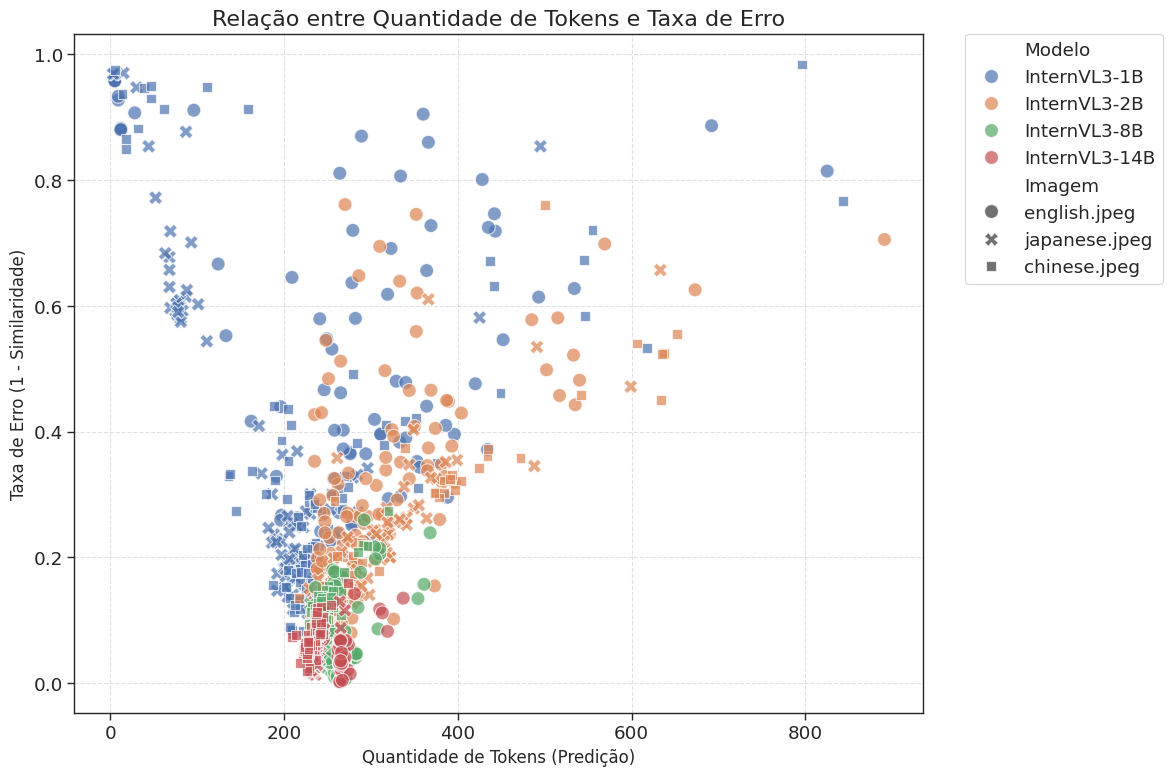

Gráfico salvo como 'scatter_tokens_vs_error.png'


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar dados se necessário
if 'df_results' not in locals() or df_results.empty:
    try:
        df_results = pd.read_csv("../results/ocr_models_comparison_results.csv")
        print(len(df_results))
        print("Dados carregados do CSV.")
    except FileNotFoundError:
        print("Nenhum dado encontrado para plotar.")
df_results_plt = df_results[df_results['Tokens (Predição)'] < 1000]
if 'df_results_plt' in locals() and not df_results_plt.empty:
    plt.figure(figsize=(12, 8))
    
    # Criar Scatter Plot
    sns.scatterplot(
        data=df_results_plt, 
        x="Tokens (Predição)", 
        y="Taxa de Erro", 
        hue="Modelo", 
        style="Imagem", 
        s=100, 
        alpha=0.7
    )
    
    plt.title("Relação entre Quantidade de Tokens e Taxa de Erro", fontsize=16)
    plt.xlabel("Quantidade de Tokens (Predição)", fontsize=12)
    plt.ylabel("Taxa de Erro (1 - Similaridade)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    
    plt.tight_layout()
    plt.savefig("../figures/scatter_tokens_vs_error.png")
    plt.show()
    print("Gráfico salvo como 'scatter_tokens_vs_error.png'")
else:
    print("Não há dados para gerar o gráfico.")

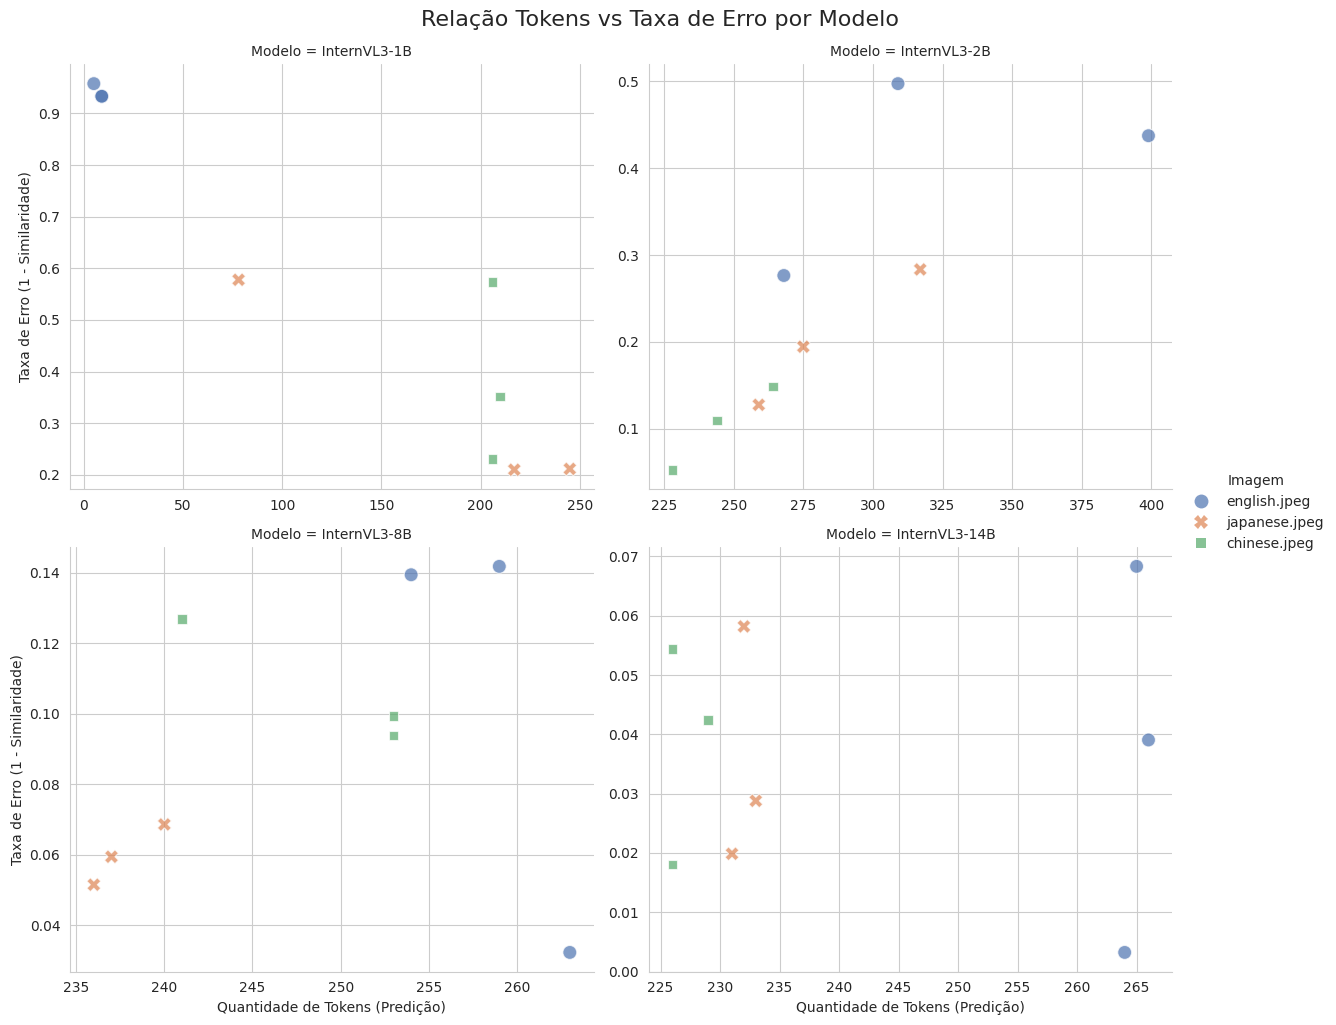

Gráfico salvo como 'scatter_tokens_vs_error_by_model.png'


In [16]:
# Gráficos separados por Modelo
if 'df_results' not in locals() or df_results.empty:
    try:
        df_results = pd.read_csv("../results/ocr_models_comparison_results.csv")
        print("Dados carregados do CSV.")
    except FileNotFoundError:
        print("Nenhum dado encontrado para plotar.")

# Filtrar outliers de tokens se necessário (mantendo a lógica anterior)
df_plot = df_results[df_results['Tokens (Predição)'] < 1000] if 'df_results' in locals() else pd.DataFrame()

if not df_plot.empty:
    # Configurar o estilo
    sns.set_style("whitegrid")
    
    # Criar FacetGrid com relplot para separar por modelo
    g = sns.relplot(
        data=df_plot,
        x="Tokens (Predição)",
        y="Taxa de Erro",
        hue="Imagem",
        style="Imagem",
        col="Modelo",
        col_wrap=2, # Organizar em 2 colunas
        kind="scatter",
        s=100,
        alpha=0.7,
        height=5,
        aspect=1.2,
        palette="deep",
        facet_kws={'sharey': False, 'sharex': False} # Eixos X e Y independentes
    )
    
    # Ajustar títulos e eixos
    g.fig.suptitle("Relação Tokens vs Taxa de Erro por Modelo", fontsize=16, y=1.02)
    g.set_axis_labels("Quantidade de Tokens (Predição)", "Taxa de Erro (1 - Similaridade)")
    
    # Salvar
    plt.savefig("../figures/scatter_tokens_vs_error_by_model.png", bbox_inches='tight')
    plt.show()
    print("Gráfico salvo como 'scatter_tokens_vs_error_by_model.png'")
else:
    print("Não há dados para gerar os gráficos.")

/tmp/ipykernel_8832/3120532069.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


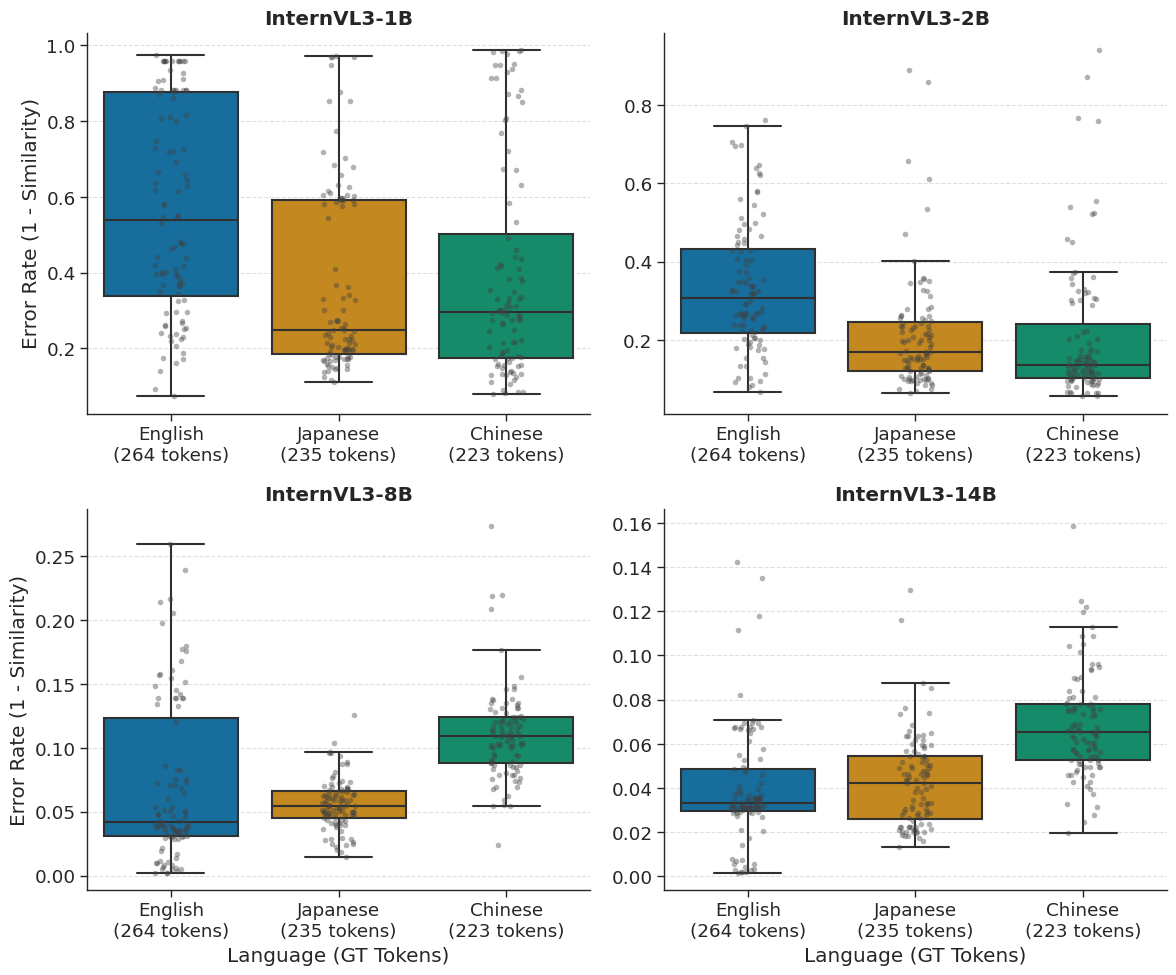

Gráfico salvo como './IEEE_Conference_WPOS__2025/Fig/boxplot_error_by_language_model.png'


In [9]:
# Boxplot separado por Modelo (Taxa de Erro por Idioma/Imagem) - Updated for Paper (Refined)
if 'df_results' not in locals() or df_results.empty:
    try:
        df_results = pd.read_csv("../results/ocr_models_comparison_results.csv")
        print("Dados carregados do CSV.")
    except FileNotFoundError:
        print("Nenhum dado encontrado para plotar.")

if 'df_results' in locals() and not df_results.empty:
    # Configurar o estilo para publicação: Fundo branco, sem grid pesado
    sns.set_theme(style="ticks", context="paper", font_scale=1.5)
    
    # Mapear nomes de arquivos para nomes de idiomas bonitos
    name_map = {
        'english.jpeg': 'English',
        'japanese.jpeg': 'Japanese',
        'chinese.jpeg': 'Chinese'
    }
    # Fallback se houver outros nomes
    df_results['Language_Name'] = df_results['Imagem'].map(lambda x: name_map.get(x, x))

    # Criar uma coluna de rótulo que inclui a contagem de tokens do gabarito
    df_results['Label_Imagem'] = df_results.apply(
        lambda row: f"{row['Language_Name']}\n({int(row['Tokens (Gabarito)'])} tokens)", axis=1
    )
    
    # Definir uma paleta de cores sóbria e profissional (Colorblind friendly)
    custom_palette = sns.color_palette("colorblind", 3)

    # Criar FacetGrid com catplot (kind='box') para separar por modelo
    g = sns.catplot(
        data=df_results,
        x="Label_Imagem",
        y="Taxa de Erro",
        col="Modelo",
        col_wrap=2, # Organizar em 2 colunas
        kind="box",
        height=5,
        aspect=1.2,
        palette=custom_palette,
        sharey=False, # Eixos Y independentes
        sharex=False,
        linewidth=1.5, # Linhas do boxplot mais finas/elegantes
        fliersize=0 # Ocultar outliers do boxplot pois usaremos stripplot
    )
    
    # Adicionar stripplot para mostrar a distribuição real dos pontos
    g.map_dataframe(sns.stripplot, x="Label_Imagem", y="Taxa de Erro", 
                    color=".25", alpha=0.4, jitter=True, size=4)

    # Ajustes finos de layout e eixos
    for ax in g.axes.flat:
        # Adicionar grid horizontal sutil
        ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.25)
        # Remover bordas desnecessárias (topo e direita já saem com style='ticks', mas garantindo)
        sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
        
    # Ajustar títulos e eixos para Inglês (Paper)
    g.set_axis_labels("Language (GT Tokens)", "Error Rate (1 - Similarity)")
    g.set_titles("{col_name}", fontweight='bold') # Títulos das colunas em negrito
    
    # Salvar com alta resolução
    output_filename = "../figures/boxplot_error_by_language_model.png"
    # Garantir que o diretório existe
    os.makedirs(os.path.dirname(output_filename), exist_ok=True)
    
    plt.savefig(output_filename, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Gráfico salvo como '{output_filename}'")
else:
    print("Não há dados para gerar os gráficos.")

In [ ]:
# Verificar o novo gabarito carregado
import csv
try:
    with open('../data/ground_truth/manual_ocr_ground_truth.csv', 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        print(f"{'Filename':<15} | {'Language':<10} | {'Text Length'}")
        print("-" * 40)
        for row in reader:
            print(f"{row['filename']:<15} | {row['language']:<10} | {len(row['text'])} chars")
            print(f"Preview: {row['text'][:50]}...")
            print("-" * 40)
except FileNotFoundError:
    print("Arquivo manual_ocr_ground_truth.csv não encontrado.")

Filename        | Language   | Text Length
----------------------------------------
english.jpeg    | English    | 925 chars
Preview: Isotopes of hydrogen
Article Talk
From Wikipedia, ...
----------------------------------------
chinese.jpeg    | Chinese    | 302 chars
Preview: 氢的同位素 [编辑]

条目 讨论 汉 漢 大陆简体

维基百科，自由的百科全书
氢（原子量：1.0...
----------------------------------------
japanese.jpeg   | Japanese   | 377 chars
Preview: 水素の同位体
ページ ノート

出典: フリー百科事典『ウィキペディア（Wikipedia）』
水素...
----------------------------------------


In [10]:
# Generate Statistic Reports (Tables) matching the requested format
import pandas as pd
import os
from IPython.display import display

# Load data
csv_file = "../results/ocr_models_comparison_results.csv"
if os.path.exists(csv_file):
    df_results = pd.read_csv(csv_file)
    
    # Map filenames to Language names
    name_map = {
        'english.jpeg': 'English',
        'japanese.jpeg': 'Japanese',
        'chinese.jpeg': 'Chinese'
    }
    df_results['Language'] = df_results['Imagem'].map(lambda x: name_map.get(x, x))

    # Define metrics and aggregation functions
    # Using 'std' for Standard Deviation (SD)
    agg_funcs = {
        'Tokens (Predição)': ['mean', 'std'],
        'Similaridade': ['mean', 'std'],
        'Taxa de Erro': ['mean', 'std']
    }

    # List of languages to generate tables for
    languages = ['English', 'Japanese', 'Chinese']

    for lang in languages:
        # Title for the table
        print(f"\nStatistic report based on 100 tests across different scale of LLM - {lang}")
        
        # Filter data for the current language
        df_lang = df_results[df_results['Language'] == lang]
        
        if df_lang.empty:
            print(f"No data found for {lang}")
            continue
            
        # Group by Model and calculate statistics
        table = df_lang.groupby('Modelo').agg(agg_funcs)
        
        # Rename columns to match the requested format (English headers)
        table.columns = pd.MultiIndex.from_tuples([
            ('Tokens (Prediction)', 'Mean'), ('Tokens (Prediction)', 'SD'),
            ('Similarity', 'Mean'), ('Similarity', 'SD'),
            ('Error rate', 'Mean'), ('Error rate', 'SD')
        ])
        
        # Format the float values for better readability
        pd.options.display.float_format = '{:.4f}'.format
        
        # Display the table
        display(table)
else:
    print("CSV file not found. Please run the experiments first.")


Statistic report based on 100 tests across different scale of LLM - English


Tokens (Prediction)          Similarity        Error rate       
                             Mean       SD       Mean     SD       Mean     SD
Modelo                                                                        
InternVL3-14B            268.0200  11.3440     0.9607 0.0259     0.0393 0.0259
InternVL3-1B             279.8100 287.1944     0.4340 0.2763     0.5660 0.2763
InternVL3-2B             326.2500 102.4026     0.6673 0.1648     0.3327 0.1648
InternVL3-8B             269.0000  20.7321     0.9295 0.0629     0.0705 0.0629


Statistic report based on 100 tests across different scale of LLM - Japanese


Tokens (Prediction)          Similarity        Error rate       
                             Mean       SD       Mean     SD       Mean     SD
Modelo                                                                        
InternVL3-14B            235.1100   6.1495     0.9573 0.0208     0.0427 0.0208
InternVL3-1B             175.8900  85.2447     0.6261 0.2460     0.3739 0.2460
InternVL3-2B             371.3200 537.3757     0.7892 0.1448     0.2108 0.1448
InternVL3-8B             236.0600   3.8266     0.9442 0.0196     0.0558 0.0196


Statistic report based on 100 tests across different scale of LLM - Chinese


Tokens (Prediction)          Similarity        Error rate       
                             Mean       SD       Mean     SD       Mean     SD
Modelo                                                                        
InternVL3-14B            231.8600   8.3158     0.9320 0.0233     0.0680 0.0233
InternVL3-1B             359.9900 586.9830     0.6057 0.2847     0.3943 0.2847
InternVL3-2B             379.8500 506.5819     0.7943 0.1745     0.2057 0.1745
InternVL3-8B             245.0300  13.6489     0.8899 0.0354     0.1101 0.0354

In [12]:
# Export Statistic Reports to Excel
import pandas as pd
import os

# Load data
csv_file = "../results/ocr_models_comparison_results.csv"
output_excel = "../results/ocr_statistics_report.xlsx"

if os.path.exists(csv_file):
    try:
        df_results = pd.read_csv(csv_file)
        
        # Map filenames to Language names
        name_map = {
            'english.jpeg': 'English',
            'japanese.jpeg': 'Japanese',
            'chinese.jpeg': 'Chinese'
        }
        df_results['Language'] = df_results['Imagem'].map(lambda x: name_map.get(x, x))

        # Define metrics and aggregation functions
        agg_funcs = {
            'Tokens (Predição)': ['mean', 'std'],
            'Similaridade': ['mean', 'std'],
            'Taxa de Erro': ['mean', 'std']
        }

        languages = ['English', 'Japanese', 'Chinese']
        
        # Create Excel Writer
        # Note: Requires 'openpyxl' library. If missing, install with: !pip install openpyxl
        with pd.ExcelWriter(output_excel) as writer:
            for lang in languages:
                df_lang = df_results[df_results['Language'] == lang]
                
                if df_lang.empty:
                    continue
                    
                # Group and Aggregate
                table = df_lang.groupby('Modelo').agg(agg_funcs)
                
                # Rename columns
                table.columns = pd.MultiIndex.from_tuples([
                    ('Tokens (Prediction)', 'Mean'), ('Tokens (Prediction)', 'SD'),
                    ('Similarity', 'Mean'), ('Similarity', 'SD'),
                    ('Error rate', 'Mean'), ('Error rate', 'SD')
                ])
                
                # Write to Excel Sheet
                table.to_excel(writer, sheet_name=lang)
                
        print(f"Statistics exported successfully to {output_excel}")
        print("You can open this file in Excel or import it into Word.")
        
    except ImportError as e:
        print(f"Error: {e}")
        print("Please install openpyxl to export to Excel: pip install openpyxl")
    except Exception as e:
        print(f"An error occurred: {e}")
else:
    print("CSV file not found. Please run the experiments first.")

Statistics exported successfully to ocr_statistics_report.xlsx
You can open this file in Excel or import it into Word.


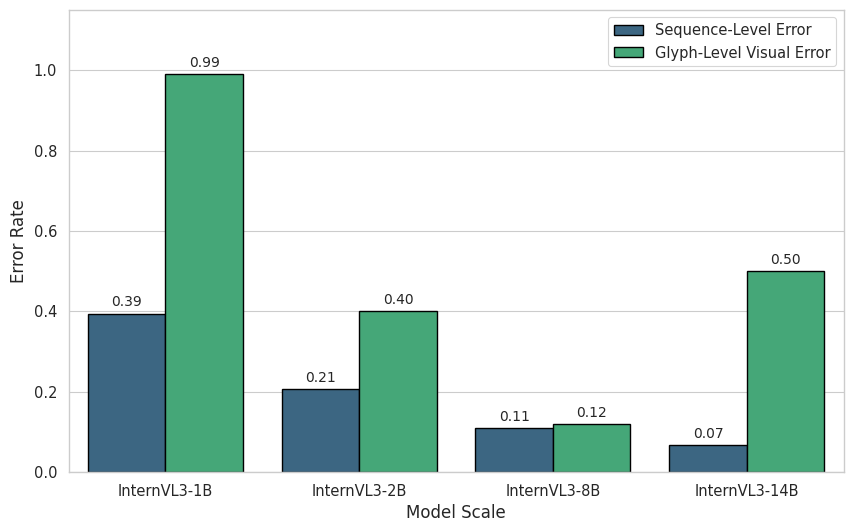

Chart saved as 'manual_error_rate_comparison.png'


In [1]:
# Manual Plot Request: Sequence-Level vs Glyph-Level Visual Error
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data provided in the request (Updated labels)
data = {
    'Model': ['InternVL3-1B', 'InternVL3-2B', 'InternVL3-8B', 'InternVL3-14B'],
    'Sequence-Level Error': [0.3943, 0.2057, 0.1101, 0.0680],
    'Glyph-Level Visual Error': [0.99, 0.4, 0.12, 0.5]
}

df_manual = pd.DataFrame(data)

# Transform to long format for plotting
df_melted = df_manual.melt(id_vars='Model', var_name='Error Type', value_name='Error Rate')

# Setup style
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.figure(figsize=(10, 6))

# Create Grouped Bar Chart
ax = sns.barplot(
    data=df_melted,
    x='Model',
    y='Error Rate',
    hue='Error Type',
    palette='viridis',
    edgecolor='black',
    linewidth=1
)

# Add labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

# Customization
# Title removed as requested
plt.xlabel('Model Scale', fontsize=12)
plt.ylabel('Error Rate', fontsize=12)
plt.legend(title=None, loc='upper right')
plt.ylim(0, 1.15)  # Add some space for labels

# Save figure
output_filename = "manual_error_rate_comparison.png"
plt.savefig(output_filename, bbox_inches='tight', dpi=300)
plt.show()
print(f"Chart saved as '{output_filename}'")

In [ ]:
# Manual Plot Request: Sequence-Level vs Glyph-Level Visual Error
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data provided in the request (Updated labels)
data = {
    'Model': ['InternVL3-1B', 'InternVL3-2B', 'InternVL3-8B', 'InternVL3-14B'],
    'Sequence-Level Error': [0.3943, 0.2057, 0.1101, 0.0680],
    'Glyph-Level Visual Error': [0.99, 0.4, 0.12, 0.5]
}

df_manual = pd.DataFrame(data)

# Transform to long format for plotting
df_melted = df_manual.melt(id_vars='Model', var_name='Error Type', value_name='Error Rate')

# Setup style
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.figure(figsize=(10, 6))

# Create Grouped Bar Chart
ax = sns.barplot(
    data=df_melted,
    x='Model',
    y='Error Rate',
    hue='Error Type',
    palette='viridis',
    edgecolor='black',
    linewidth=1
)

# Add labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

# Customization
# Title removed as requested
plt.xlabel('Model Scale', fontsize=12)
plt.ylabel('Error Rate', fontsize=12)
plt.legend(title=None, loc='upper right')
plt.ylim(0, 1.15)  # Add some space for labels

# Save figure
output_filename = "manual_error_rate_comparison.png"
plt.savefig(output_filename, bbox_inches='tight', dpi=300)
plt.show()
print(f"Chart saved as '{output_filename}'")

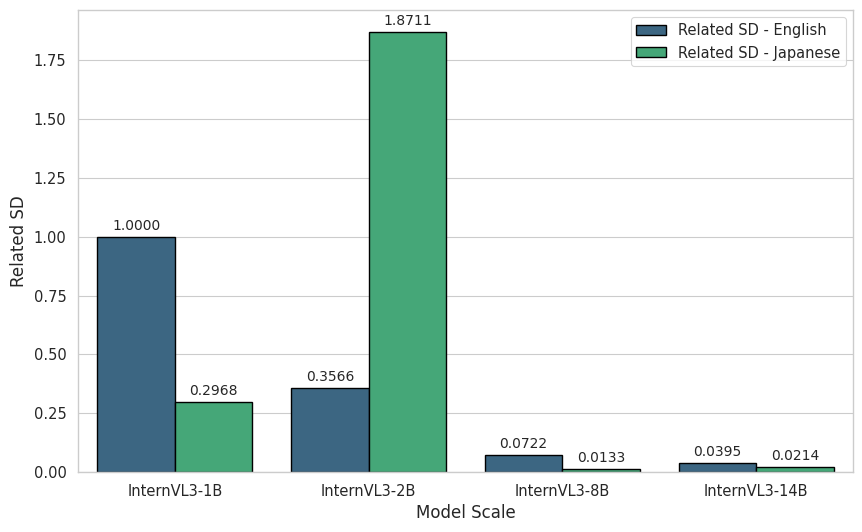

Chart saved as 'related_sd_comparison.png'


In [3]:
# Manual Plot Request: Related SD (English vs Japanese)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data provided
data_sd = {
    'Model': ['InternVL3-1B', 'InternVL3-2B', 'InternVL3-8B', 'InternVL3-14B'],
    'Related SD - English': [1.0000, 0.3566, 0.0722, 0.0395],
    'Related SD - Japanese': [0.2968, 1.8711, 0.0133, 0.0214]
}

df_sd = pd.DataFrame(data_sd)

# Transform to long format
df_sd_melted = df_sd.melt(id_vars='Model', var_name='Language', value_name='Related SD')

# Setup style
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.figure(figsize=(10, 6))

# Create Grouped Bar Chart
ax = sns.barplot(
    data=df_sd_melted,
    x='Model',
    y='Related SD',
    hue='Language',
    palette='viridis', # Changed to match previous plot style
    edgecolor='black',
    linewidth=1
)

# Add labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3, fontsize=10)

# Customization
# Title removed as requested
plt.xlabel('Model Scale', fontsize=12)
plt.ylabel('Related SD', fontsize=12)
plt.legend(title=None, loc='upper right')

# Save figure
output_filename_sd = "related_sd_comparison.png"
plt.savefig(output_filename_sd, bbox_inches='tight', dpi=300)
plt.show()
print(f"Chart saved as '{output_filename_sd}'")

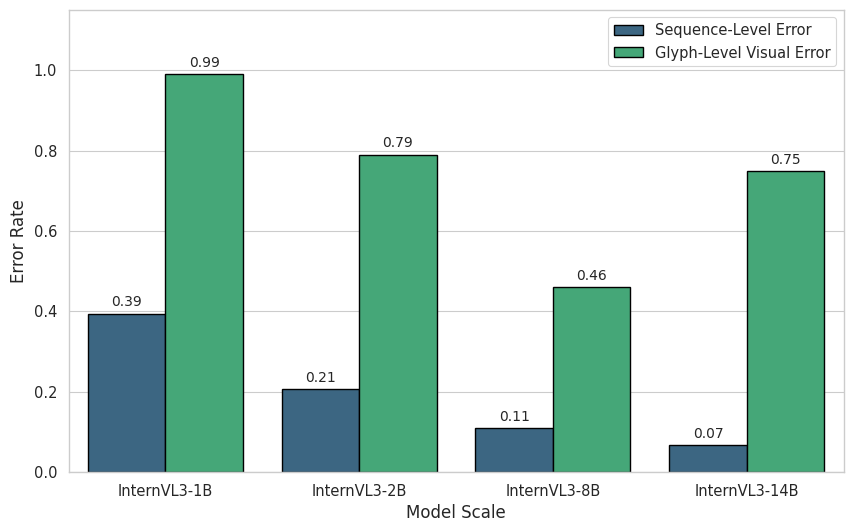

Chart saved as 'figure_1_updated.png' with high resolution (600 DPI)


In [2]:
# Updated Figure 1 Request: Sequence-Level vs Glyph-Level Visual Error (New Data)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data provided in the request (Updated Glyph-Level Visual Error)
data_updated = {
    'Model': ['InternVL3-1B', 'InternVL3-2B', 'InternVL3-8B', 'InternVL3-14B'],
    'Sequence-Level Error': [0.3943, 0.2057, 0.1101, 0.0680],
    'Glyph-Level Visual Error': [0.99, 0.79, 0.46, 0.75]
}

df_updated = pd.DataFrame(data_updated)

# Transform to long format for plotting
df_melted_updated = df_updated.melt(id_vars='Model', var_name='Error Type', value_name='Error Rate')

# Setup style
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.figure(figsize=(10, 6))

# Create Grouped Bar Chart
ax = sns.barplot(
    data=df_melted_updated,
    x='Model',
    y='Error Rate',
    hue='Error Type',
    palette='viridis',
    edgecolor='black',
    linewidth=1
)

# Add labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

# Customization
plt.xlabel('Model Scale', fontsize=12)
plt.ylabel('Error Rate', fontsize=12)
plt.legend(title=None, loc='upper right')
plt.ylim(0, 1.15)  # Add some space for labels

# Save figure with high resolution
output_filename_updated = "figure_1_updated.png"
plt.savefig(output_filename_updated, bbox_inches='tight', dpi=600)
plt.show()
print(f"Chart saved as '{output_filename_updated}' with high resolution (600 DPI)")